# Analysis of PM2.5 Air Pollution Data
**Seminar on Data Mining**  
**Author:** Enel Yusifli

## Introduction

Air pollution is an important environmental and public health issue.
PM2.5 particles are especially harmful because they can enter deep into the respiratory system.

The aim of this project is to analyze PM2.5 air pollution data and explore how pollution levels vary over time and across months.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/air_quality.csv", sep=None, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()
df.head()

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
0,IN,NaN,"Ramachandrapuram, Hyderabad - TSPCB","17.528544, 78.286195",O3,caaqm,µg/m³,8.22,2022-10-31T05:00:00+03:00,India
1,IN,NaN,"New Malakpet, Hyderabad - TSPCB","17.37206, 78.50864",PM2.5,caaqm,µg/m³,19.67,2022-10-31T05:00:00+03:00,India
2,IN,NaN,"Bombay Castel, Ooty - TNPCB","11.4068288, 76.7138973",SO2,caaqm,µg/m³,40.04,2022-10-15T13:45:00+03:00,India
3,IN,NaN,"Sona College of Technology, Salem - TNPCB","11.679111, 78.125052",SO2,caaqm,µg/m³,-3.23,2022-10-03T15:30:00+03:00,India
4,IN,NaN,"PSG College of Arts and Science, Coimbatore - ...","11.0328, 77.0349",NO2,caaqm,µg/m³,18.41,2022-10-31T05:00:00+03:00,India


## Dataset

The dataset comes from the OpenAQ platform, which provides public air quality measurements from monitoring stations.

The dataset includes information such as:
- country code
- city and location
- pollutant type
- measured value
- timestamp of measurement

This analysis focuses on PM2.5 values.

## Data Preparation

The following preprocessing steps were performed:
- filtering the dataset to keep only PM2.5 observations
- converting the "Last Updated" column to datetime format
- removing rows with missing dates
- removing invalid or extreme values

In [53]:
pm25 = df[df["Pollutant"] == "PM2.5"].copy()
pm25["Last Updated"] = pd.to_datetime(pm25["Last Updated"], errors="coerce", utc=True)
pm25 = pm25.dropna(subset=["Last Updated"])

pm25_clean = pm25[(pm25["Value"] >= 0) & (pm25["Value"] <= 500)].copy()
pm25_clean.head()

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
1,IN,NaN,"New Malakpet, Hyderabad - TSPCB","17.37206, 78.50864",PM2.5,caaqm,µg/m³,19.67,2022-10-31 02:00:00+00:00,India
12,IT,NaN,PARCO MONTECUCCO,"45.0385, 9.6693",PM2.5,Arpae Emilia-Romagna,µg/m³,9.00,2020-05-05 23:00:00+00:00,Italy
15,IT,Roma,Civ. Villa Albani,"42.099363, 11.798061",PM2.5,ARPALAZIO,µg/m³,11.00,2025-01-10 00:00:00+00:00,Italy
21,IT,Rieti,Rieti 1,"42.404092999999996, 12.858224000000002",PM2.5,ARPALAZIO,µg/m³,13.00,2025-01-10 00:00:00+00:00,Italy
22,IT,Roma,Fiumicino Villa Guglielmi,"41.768189, 12.237048",PM2.5,ARPALAZIO,µg/m³,13.00,2025-01-10 00:00:00+00:00,Italy


## Analysis

## Average PM2.5 Over Time

To examine how air pollution changes over time, the cleaned PM2.5 measurements are grouped by date and the average daily concentration is calculated.

This analysis helps reveal fluctuations in pollution levels across the observed period and makes it possible to identify periods with higher or lower average PM2.5 concentrations.

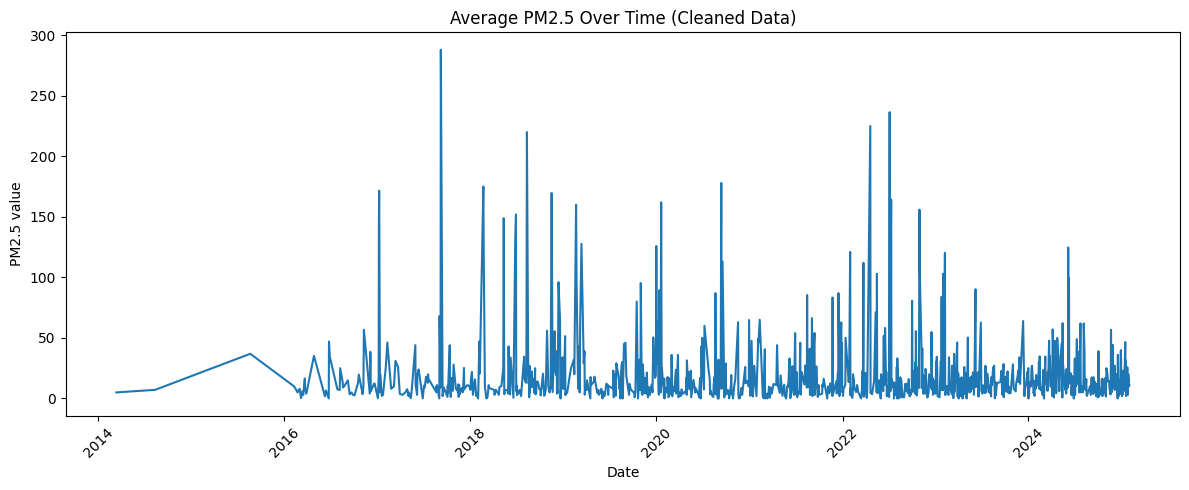

In [54]:
daily_pm25 = pm25_clean.groupby(pm25_clean["Last Updated"].dt.date)["Value"].mean()

plt.figure(figsize=(12,5))
daily_pm25.plot()
plt.title("Average PM2.5 Over Time (Cleaned Data)")
plt.xlabel("Date")
plt.ylabel("PM2.5 value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The time series plot illustrates how average PM2.5 concentrations change over time in the dataset.

The graph shows noticeable fluctuations in pollution levels across the observed period. These fluctuations may be influenced by factors such as seasonal weather conditions, variations in industrial activity, or temporary pollution events.

Time-series analysis helps identify long-term trends and periods of higher pollution levels.

## Average PM2.5 by Month

To investigate possible seasonal patterns in air pollution, the cleaned PM2.5 data is grouped by month and the average concentration is calculated for each month.

This analysis helps compare pollution levels across different parts of the year and may indicate whether certain months tend to have consistently higher or lower PM2.5 concentrations.

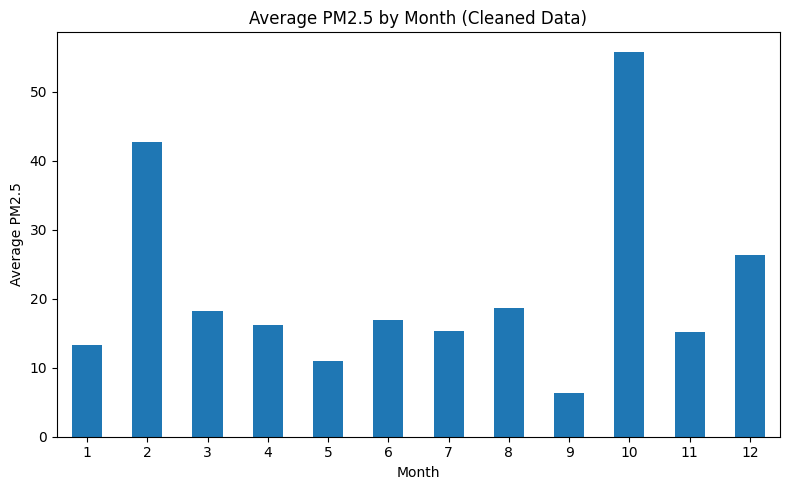

In [55]:
pm25_clean["Month"] = pm25_clean["Last Updated"].dt.month
monthly_pm25 = pm25_clean.groupby("Month")["Value"].mean()

plt.figure(figsize=(8,5))
monthly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Month (Cleaned Data)")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The monthly average PM2.5 values help reveal potential seasonal patterns in air pollution.

Certain months appear to have higher average pollution levels than others. Seasonal differences in pollution may occur due to heating during colder months, weather conditions that trap pollutants in the atmosphere, or changes in human activity throughout the year.

## Distribution of PM2.5 Concentrations

To better understand the overall behavior of PM2.5 values in the dataset, a histogram is used to show how frequently different concentration levels occur.

This analysis helps identify the most common pollution ranges, detect whether the data is concentrated around lower values, and observe the presence of less frequent high-pollution events.

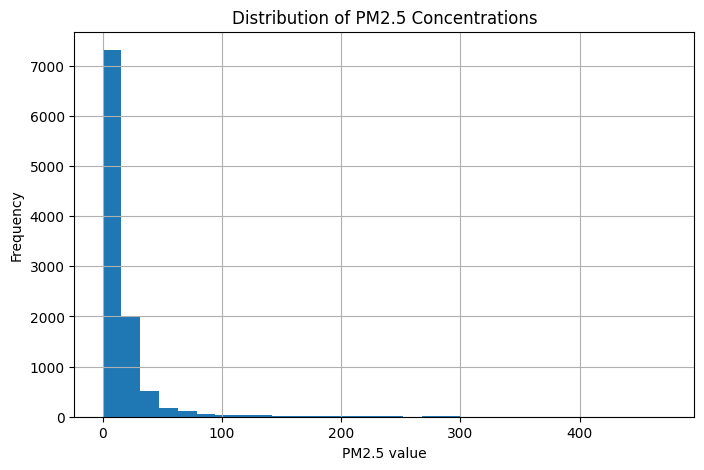

In [56]:
plt.figure(figsize=(8,5))
pm25_clean["Value"].hist(bins=30)
plt.title("Distribution of PM2.5 Concentrations")
plt.xlabel("PM2.5 value")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of PM2.5 values in the dataset.

Most measurements fall within relatively low pollution ranges, while a smaller number of observations represent higher pollution events. This indicates that extreme pollution levels occur less frequently but still play an important role in understanding air quality dynamics.

## PM2.5 Levels by Country

To explore geographic differences in air pollution levels, the dataset is grouped by country and the average PM2.5 concentration is calculated for each country.

This analysis helps identify which countries in the dataset tend to have higher average pollution levels and provides additional insight into global air quality patterns.

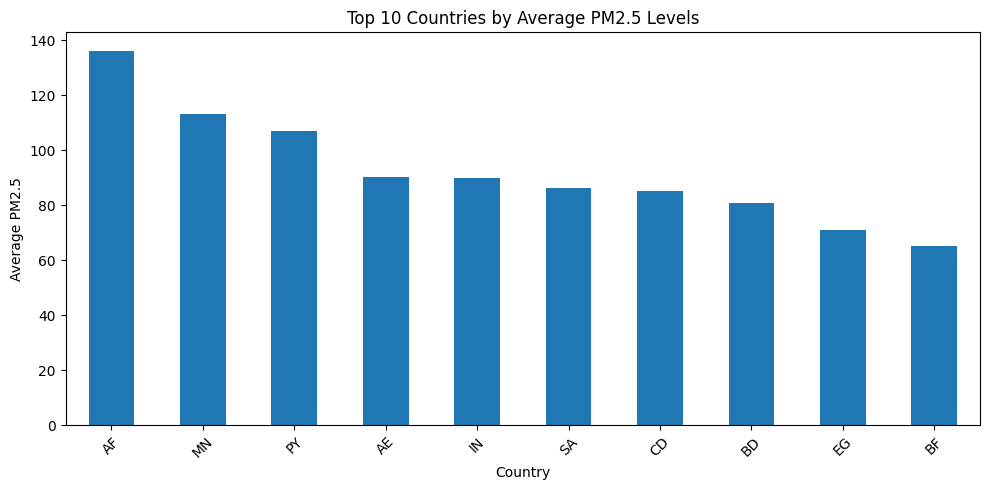

In [57]:
country_avg = pm25_clean.groupby("Country Code")["Value"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_avg.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Average PM2.5 Levels")
plt.xlabel("Country")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows the ten countries with the highest average PM2.5 concentrations in the cleaned dataset.

The results suggest that average pollution levels differ substantially across countries. These differences may be related to factors such as industrial activity, traffic intensity, population density, environmental regulation, energy use, and local geographic or climatic conditions.

This comparison adds a geographic dimension to the analysis and helps illustrate how air pollution patterns vary internationally.

## Spatial Distribution of PM2.5 Measurements

To extend the analysis with a spatial perspective, the PM2.5 observations are visualized on a world map using their geographic coordinates.

This map helps show where the measurements in the dataset were recorded and complements the temporal and statistical analysis with a geographic overview.

In [60]:
import geopandas as gpd
from shapely.geometry import Point

coords_df = pm25_clean.copy()

coords_split = coords_df["Coordinates"].str.split(",", expand=True)
coords_df["Latitude"] = pd.to_numeric(coords_split[0], errors="coerce")
coords_df["Longitude"] = pd.to_numeric(coords_split[1], errors="coerce")

coords_df = coords_df.dropna(subset=["Latitude", "Longitude"]).copy()

geometry = [Point(xy) for xy in zip(coords_df["Longitude"], coords_df["Latitude"])]
pm25_geo = gpd.GeoDataFrame(coords_df, geometry=geometry, crs="EPSG:4326")

pm25_geo.head()

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label,Month,Latitude,Longitude,geometry
1,IN,NaN,"New Malakpet, Hyderabad - TSPCB","17.37206, 78.50864",PM2.5,caaqm,µg/m³,19.67,2022-10-31 02:00:00+00:00,India,10,17.372060,78.508640,POINT (78.50864 17.37206)
12,IT,NaN,PARCO MONTECUCCO,"45.0385, 9.6693",PM2.5,Arpae Emilia-Romagna,µg/m³,9.00,2020-05-05 23:00:00+00:00,Italy,5,45.038500,9.669300,POINT (9.6693 45.0385)
15,IT,Roma,Civ. Villa Albani,"42.099363, 11.798061",PM2.5,ARPALAZIO,µg/m³,11.00,2025-01-10 00:00:00+00:00,Italy,1,42.099363,11.798061,POINT (11.79806 42.09936)
21,IT,Rieti,Rieti 1,"42.404092999999996, 12.858224000000002",PM2.5,ARPALAZIO,µg/m³,13.00,2025-01-10 00:00:00+00:00,Italy,1,42.404093,12.858224,POINT (12.85822 42.40409)
22,IT,Roma,Fiumicino Villa Guglielmi,"41.768189, 12.237048",PM2.5,ARPALAZIO,µg/m³,13.00,2025-01-10 00:00:00+00:00,Italy,1,41.768189,12.237048,POINT (12.23705 41.76819)


In [61]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

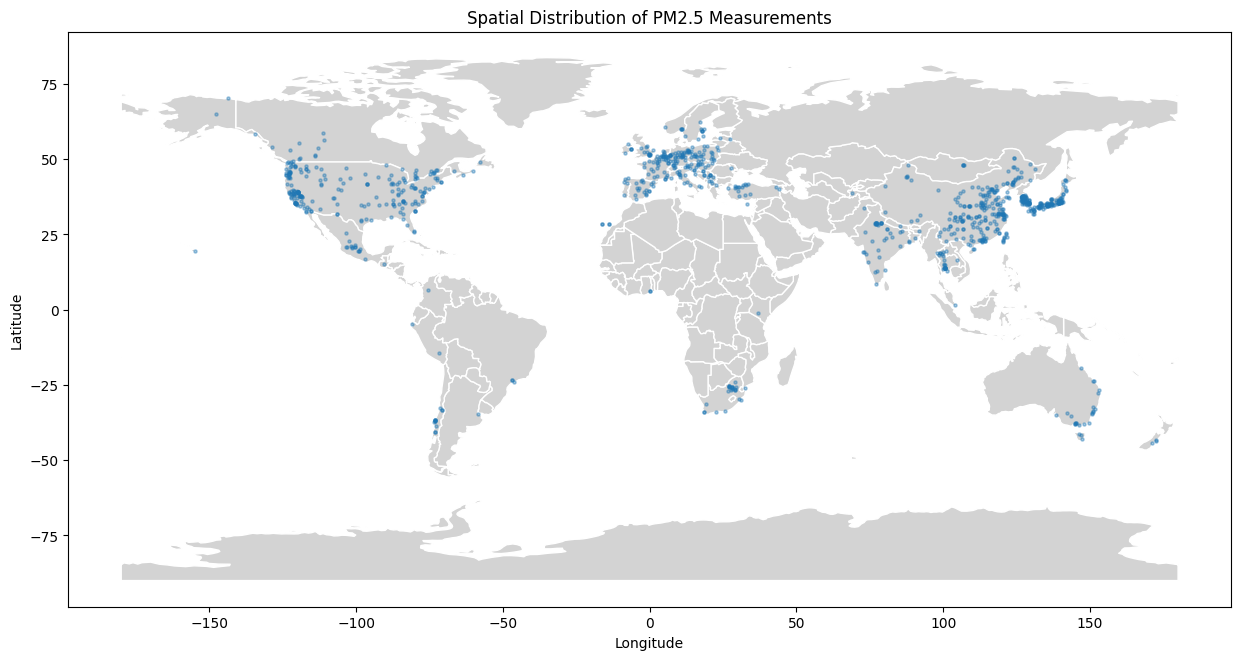

In [62]:
fig, ax = plt.subplots(figsize=(15, 8))

world.plot(ax=ax, color="lightgray", edgecolor="white")
pm25_geo.sample(min(1000, len(pm25_geo)), random_state=42).plot(
    ax=ax,
    markersize=5,
    alpha=0.4
)

plt.title("Spatial Distribution of PM2.5 Measurements")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

The map shows the geographic distribution of PM2.5 measurements included in the dataset.

The observations are spread across multiple countries and regions, which highlights the broad spatial coverage of the data. This visualization complements the previous analyses by showing where the pollution measurements were recorded and adds a geographic dimension to the project.

## Conclusion

This project analyzed PM2.5 air pollution measurements from the OpenAQ dataset. The analysis included data cleaning, time-series visualization, seasonal analysis, distribution analysis, and a comparison of pollution levels across countries.

The results demonstrate that PM2.5 concentrations vary over time and across months, suggesting possible seasonal influences. Additionally, the comparison between countries highlights substantial geographic differences in pollution levels.

These findings illustrate how environmental datasets can be explored using data analysis techniques to better understand patterns in air pollution.